In [28]:
import gymnasium as gym
import numpy as np

from q_learning import EpsilonGreedy, Qlearning
from quantile_regression import QuantileRegression
from dist_run import Params, run_env, save_experiment, load_experiment
from envs.register import register_envs

register_envs()

params = Params(
    model_name="WindyRooms-v1",
    total_episodes=10_000,
    learning_rate=0.1,
    gamma=0.99,
    epsilon=0.1,
    map_size=(14, 11),
    seed=123,
    is_slippery=True,
    n_runs=5,
    action_size=None,
    state_size=None,
    n_quantiles=32,
    use_lr_decay=True,
    save_skip=100,
    huber_k=0
)
rng = np.random.default_rng(params.seed)

In [29]:
env = gym.make(
    params.model_name,
    # is_slippery=params.is_slippery,
    shape=params.map_size,
    step_reward=0,
    goal_reward=1,
    render_mode="rgb_array",
)
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
env.action_space.seed(params.seed)

learner = QuantileRegression(params)
explorer = EpsilonGreedy(params.epsilon, rng)
tables = run_env(env, learner, explorer, params)

save_experiment(tables, params)

Run 4/5 - Episodes: 100%|██████████| 10000/10000 [06:46<00:00, 24.59it/s] 


In [30]:
params = Params(
    model_name="WindyRooms-v1",
    total_episodes=10_000,
    learning_rate=0.1,
    gamma=0.99,
    epsilon=0.1,
    map_size=(14, 11),
    seed=256,
    is_slippery=True,
    n_runs=10,
    action_size=None,
    state_size=None,
    n_quantiles=32,
    use_lr_decay=True,
    save_skip=100,
    huber_k=0
)
rng = np.random.default_rng(params.seed)

In [31]:
env = gym.make(
    params.model_name,
    # is_slippery=params.is_slippery,
    shape=params.map_size,
    step_reward=0,
    goal_reward=1,
    render_mode="rgb_array",
)
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
env.action_space.seed(params.seed)

learner = QuantileRegression(params)
explorer = EpsilonGreedy(params.epsilon, rng)
tables = run_env(env, learner, explorer, params)

save_experiment(tables, params)

Run 9/10 - Episodes: 100%|██████████| 10000/10000 [04:14<00:00, 39.25it/s] 


In [44]:
from dist_run import load_experiment

params, tables = load_experiment()
tables = tables.mean(0)
qtables = tables.mean(-1) if params.n_quantiles > 1 else tables[-1]
qtable = qtables[-1]

In [22]:
from tqdm import tqdm

test_episodes = 10_000

env = gym.make(
    params.model_name,
    render_mode="rgb_array",
)

total_rewards = []
for episode in tqdm(range(test_episodes)):
    state, info = env.reset() # seed=params.seed?
    done = False
    total_reward = 0

    while not done:
        action = np.argmax(qtable[state])
        next_state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        state = next_state
        done = terminated or truncated

    total_rewards.append(total_reward)

  0%|          | 0/10000 [00:06<?, ?it/s]


KeyboardInterrupt: 

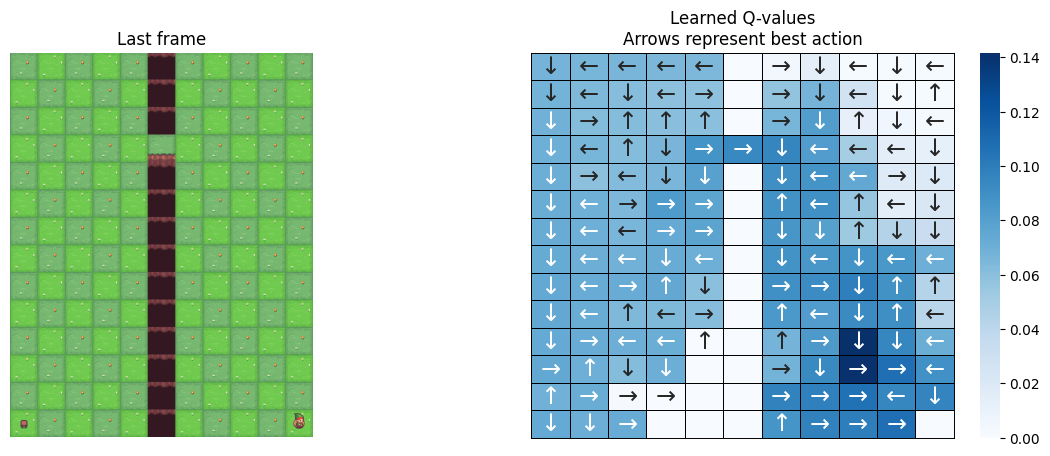

In [45]:
from dist_plot import plot_q_values_map

plot_q_values_map(qtable, env, params.map_size)

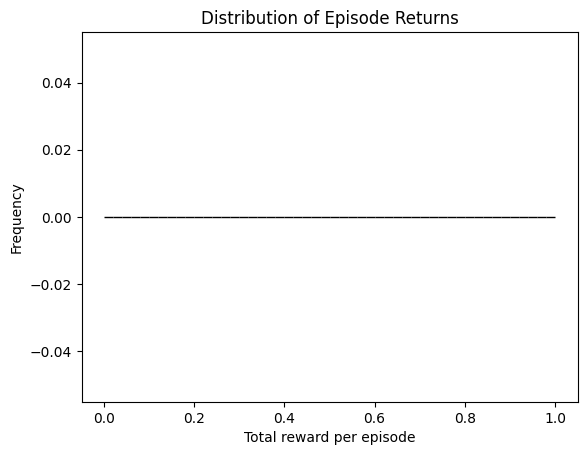

In [46]:
import matplotlib.pyplot as plt

plt.hist(total_rewards, bins=50, edgecolor="black")
plt.xlabel("Total reward per episode")
plt.ylabel("Frequency")
plt.title("Distribution of Episode Returns")
plt.show()